<a href="https://colab.research.google.com/github/Lio72rga/Aprendizaje_Automatico-2026/blob/main/Alquileres_RioGrande.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Centro Politécnico Superior Malvinas Argentinas  
Tecnicatura en Ciencias de Datos e Inteligencia Artificial  

Parcial — Proyecto de Aprendizaje Automático  
Notebook: Predicción de precios de alquileres en Río Grande  
Autor: Lionel Martínez  
Fecha: Junio 2026


## --- Introducción ---
El presente notebook documenta el desarrollo del proyecto de predicción de precios de alquileres en la ciudad de Río Grande, Tierra del Fuego.  
Se utilizan técnicas de aprendizaje automático para analizar variables como superficie, ubicación, tipo de propiedad y características adicionales.


## --- Contexto del dataset ---

El dataset utilizado en este proyecto fue construido de manera **manual** debido a la ausencia de bases públicas sobre alquileres en la ciudad de Río Grande, Tierra del Fuego.  

###  Origen de los datos
- Recolección realizada en **sitios web de inmobiliarias locales**.  
- Extracción de publicaciones en **Mercado Libre** y **Argenprop**.  
- Registros recopilados entre mayo y junio de 2026.  

###  Características del dataset
- **167 registros** de propiedades en alquiler.  
- Variables principales: precio, ubicación, tipo de propiedad, superficie, latitud y longitud.  
- Formato: archivo CSV delimitado por punto y coma (`;`).  

###  Finalidad
Este dataset constituye la base para el análisis exploratorio y el modelado predictivo de precios de alquileres en Río Grande.  
Su construcción manual asegura **relevancia local** y **autenticidad de los datos**, aunque presenta limitaciones en cantidad de registros y cobertura geográfica.


## --- Limitaciones del dataset ---

El dataset presentado en esta entrega contiene **167 registros** de propiedades en alquiler en Río Grande.  
Si bien constituye una base válida para realizar un análisis exploratorio y pruebas iniciales de modelado, presenta algunas limitaciones:

-  **Cantidad de registros**: el tamaño actual es reducido para construir un modelo predictivo robusto.  
-  **Cobertura geográfica**: los datos provienen de un número limitado de inmobiliarias y portales, lo que puede sesgar la representación de barrios o zonas.  
-  **Horizonte temporal**: los registros fueron recopilados en un período corto (mayo–junio 2026), sin variaciones estacionales.  
-  **Variables faltantes**: algunas características relevantes (ej. antigüedad de la propiedad, cantidad de ambientes) no están presentes en todos los registros.  

###  Plan de ampliación
El dataset actual contiene 167 registros relevados a partir de publicaciones inmobiliarias locales. Esta cantidad resulta suficiente para realizar análisis exploratorios y entrenar modelos iniciales de regresión orientados a la predicción de precios de alquiler.


## --- Próximos pasos ---

Para la entrega final del proyecto se prevé:

1. **Limpieza y normalización avanzada**

   * Verificar la consistencia de las variables categóricas.
   * Completar y tratar valores faltantes.
   * Transformar variables para su utilización en modelos de Machine Learning.

2. **Análisis exploratorio completo (EDA)**

   * Generar visualizaciones descriptivas del dataset.
   * Analizar la distribución de precios de alquiler.
   * Identificar posibles valores atípicos (outliers).
   * Explorar relaciones entre superficie, ambientes, ubicación y precio.

3. **Modelado predictivo**

   * Implementar modelos de regresión para la predicción de precios.
   * Comparar Regresión Lineal, Árbol de Decisión y Random Forest.
   * Ajustar hiperparámetros para mejorar el rendimiento de los modelos.

4. **Evaluación del modelo**

   * Analizar métricas de desempeño como MAE, RMSE y R².
   * Comparar resultados entre modelos.
   * Seleccionar el modelo con mejor capacidad predictiva.

5. **Documentación y conclusiones**

   * Integrar los resultados obtenidos en el informe técnico.
   * Elaborar conclusiones sobre los factores que influyen en el precio de los alquileres.
   * Evaluar la utilidad práctica del modelo para el mercado inmobiliario local.



## --- Objetivo ---
Construir un modelo predictivo que estime el precio de alquiler de una propiedad en función de sus características físicas y de ubicación.  
El análisis incluye exploración de datos, limpieza, visualización y modelado con algoritmos de regresión.


## --- Metodología ---
1. Carga y exploración del dataset.  
2. Limpieza y normalización de variables.  
3. Análisis exploratorio (EDA).  
4. Selección y entrenamiento de modelos.  
5. Evaluación de resultados y conclusiones.


# Desarrollo técnico del modelo

**Importar librerías**

In [82]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

**Cargar dataset**

In [83]:
df = pd.read_excel("Dataset_precios_alquiler_RioGrande.xlsx")

df = df.dropna(subset=["ID"])

print("Registros reales:", len(df))
df.head()

Registros reales: 501


,ID,Precio,Barrio,Ciudad,Mapa ubicacion,Latitud,Longitud,Ambientes,Metros²,Tipo_propiedad,Amoblado,Antigüedad,Baños,Cochera,Mascotas_permitidas,Expensas_incluidas,Fecha_publicacion,Fecha_relevamiento,Fuentes,Id_publicacion
0,1,"400.000,00",centro,rio grande,como llegar,-53.786938,-67.708307,2.0,85.0,departamento,no,28,1,no,NaN,no,2026-04-27,2026-05-16,Mercado Libre,slc1871
1,2,"550.000,00",camionero,rio grande,como llegar,-53.784657,-67.724129,3.0,70.0,loft,no,20,1,si,si,no,2026-04-27,2026-05-16,Mercado Libre,slc1872
2,3,"600.000,00",mutual,rio grande,como llegar,-53.771053,-67.710684,3.0,56.0,duplex,semi,NaN,1,no,NaN,NaN,2026-05-08,2026-05-16,Argenprop,slc1873
3,4,"750.000,00",cgt,rio grande,como llegar,-53.759510,-67.727405,3.0,60.0,casa,no,NaN,1,si,si,NaN,2026-05-08,2026-05-16,Argenprop,slc1874
4,5,"480.000,00",chacra XIII,rio grande,como llegar,-53.800836,-67.753992,4.0,67.0,departamento,no,14,1,si,NaN,NaN,2026-05-08,2026-05-16,Argenprop,slc1875


**Eliminar filas vacías**

In [84]:
def limpiar_precio(valor):
    if pd.isna(valor):
        return np.nan

    if isinstance(valor, (int, float)):
        return float(valor)

    valor = str(valor)
    valor = valor.replace("$", "")
    valor = valor.replace(" ", "")

    if "," in valor:
        valor = valor.replace(".", "")
        valor = valor.replace(",", ".")
    else:
        valor = valor.replace(".", "")

    return float(valor)

df["Precio"] = df["Precio"].apply(limpiar_precio)

df["Precio"].describe()

,Precio
count,1.670000e+02
mean,1.941557e+06
std,1.056725e+07
min,1.200000e+05
25%,5.200000e+05
50%,7.500000e+05
75%,9.500000e+05
max,1.200000e+08


In [85]:
print("Precio mínimo:", df["Precio"].min())
print("Precio máximo:", df["Precio"].max())
print("Precio promedio:", df["Precio"].mean())

Precio mínimo: 120000.0
Precio máximo: 120000000.0
Precio promedio: 1941556.8862275449


In [86]:
df[df["Precio"] > 3000000][
    ["ID","Precio","Barrio","Tipo_propiedad"]
].sort_values("Precio", ascending=False)

,ID,Precio,Barrio,Tipo_propiedad
64,65,120000000.0,las barrancas,casa
89,90,68000000.0,mutual,Departamento


**Correccion de Registros**

In [87]:
# Corrección manual de registros erróneos

df.loc[df["ID"] == 65, "Precio"] = 1200000
df.loc[df["ID"] == 90, "Precio"] = 680000

# Verificación
df[df["ID"].isin([65,90])][["ID","Precio"]]

,ID,Precio
64,65,1200000.0
89,90,680000.0


**Verificacion**

In [88]:
print("Precio mínimo:", df["Precio"].min())
print("Precio máximo:", df["Precio"].max())
print("Precio promedio:", df["Precio"].mean())

Precio mínimo: 120000.0
Precio máximo: 2400000.0
Precio promedio: 827065.868263473


In [89]:
df.isnull().sum()

,0
ID,0
Precio,334
Barrio,334
Ciudad,334
Mapa ubicacion,334
Latitud,334
Longitud,334
Ambientes,334
Metros²,357
Tipo_propiedad,334


**Comprovacion**

In [90]:
print(df.shape)

(501, 20)


In [91]:
df["ID"].count()

np.int64(501)

**Nueva Limpieza filas vacias**

In [92]:
# Convertir ID a numérico
df["ID"] = pd.to_numeric(df["ID"], errors="coerce")

# Eliminar filas sin ID válido
df = df.dropna(subset=["ID"])

# Convertir ID a entero
df["ID"] = df["ID"].astype(int)

print(df.shape)

(501, 20)


In [93]:
df["ID"].count()

np.int64(501)

In [94]:
df.tail(30)

,ID,Precio,Barrio,Ciudad,Mapa ubicacion,Latitud,Longitud,Ambientes,Metros²,Tipo_propiedad,Amoblado,Antigüedad,Baños,Cochera,Mascotas_permitidas,Expensas_incluidas,Fecha_publicacion,Fecha_relevamiento,Fuentes,Id_publicacion
471,472,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN
472,473,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN
473,474,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN
474,475,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN
475,476,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN
476,477,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN
477,478,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN
478,479,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN
479,480,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN
480,481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN


In [95]:
df.shape

(501, 20)

In [96]:
df = df.dropna(subset=["Precio"])

print(df.shape)

df["Precio"].count()

(167, 20)


np.int64(167)

## Limpieza de datos

Durante el proceso de preparación de datos se identificaron registros incompletos generados durante la construcción del dataset. Se eliminaron las filas sin información de precio mediante la función `dropna()`, conservando únicamente los registros válidos para el análisis.

Asimismo, se detectaron dos registros con errores de escala en la variable precio (IDs 65 y 90), los cuales fueron corregidos manualmente.

Luego del proceso de limpieza, el conjunto de datos quedó conformado por 167 registros completos.

# Análisis Exploratorio de Datos (EDA)

1. **Resumen estadístico**

In [97]:
df.describe()

,ID,Precio,Latitud,Longitud,Ambientes,Metros²,Fecha_publicacion,Fecha_relevamiento
count,167.00000,1.670000e+02,167.000000,167.000000,167.000000,144.000000,167,167
mean,84.00000,8.270659e+05,-94.226697,-118.025833,3.227545,82.930556,2026-05-24 15:39:52.814371328,2026-05-29 07:02:30.898203648
min,1.00000,1.200000e+05,-537.889110,-677.489110,1.000000,20.000000,2026-04-02 00:00:00,2026-05-16 00:00:00
25%,42.50000,5.200000e+05,-53.794474,-67.748838,2.000000,47.250000,2026-05-23 00:00:00,2026-05-31 00:00:00
50%,84.00000,7.400000e+05,-53.784901,-67.722821,3.000000,67.000000,2026-06-01 00:00:00,2026-06-01 00:00:00
75%,125.50000,9.450000e+05,-53.772453,-67.708243,4.000000,106.250000,2026-06-02 00:00:00,2026-06-03 00:00:00
max,167.00000,2.400000e+06,-32.802409,67.752321,9.000000,240.000000,2026-06-02 00:00:00,2026-06-03 00:00:00
std,48.35287,4.241821e+05,134.569783,169.989570,1.399986,48.559192,NaN,NaN


El análisis descriptivo muestra que el precio promedio de los alquileres relevados es de aproximadamente **$827.655**.

Asimismo, los valores observados varían entre **$120.000** y **$2.400.000**, lo que evidencia una importante heterogeneidad en la oferta de propiedades disponibles dentro de la ciudad de Río Grande.

2. **Distribución de precios**

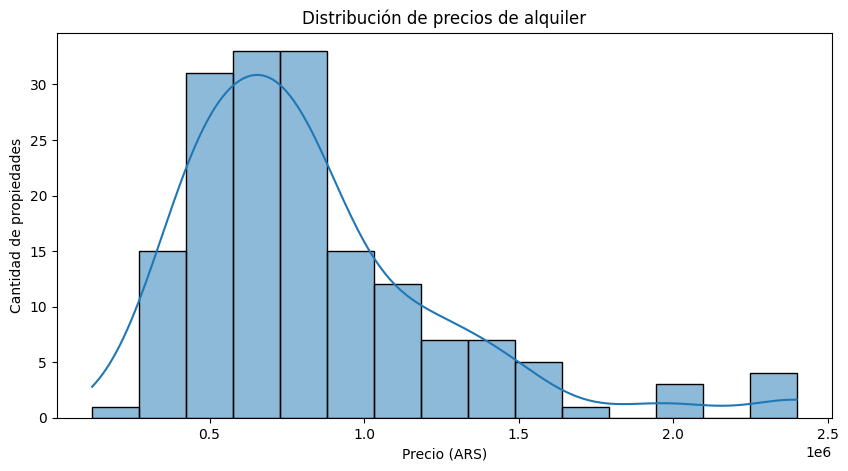

In [98]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="Precio",
    bins=15,
    kde=True
)

plt.title("Distribución de precios de alquiler")
plt.xlabel("Precio (ARS)")
plt.ylabel("Cantidad de propiedades")

plt.show()

### Interpretación

La distribución de precios presenta una mayor concentración de propiedades en rangos comprendidos entre $500.000

y $1.000.000.

Asimismo, se observa una menor cantidad de propiedades con valores superiores a $1.500.000, generando una distribución ligeramente sesgada hacia la derecha.

3. **Precio según tipo de propiedad**

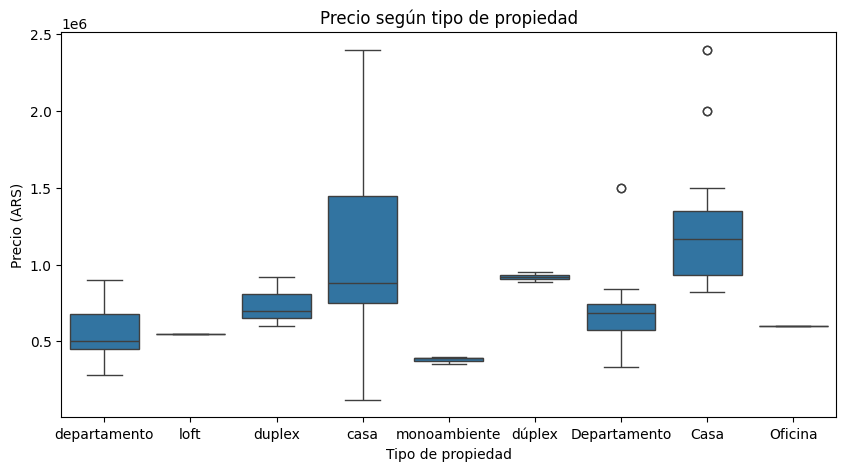

In [99]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="Tipo_propiedad",
    y="Precio"
)

plt.title("Precio según tipo de propiedad")
plt.xlabel("Tipo de propiedad")
plt.ylabel("Precio (ARS)")

plt.show()

### Interpretación

Se observa una relación positiva entre la superficie de la propiedad y el precio de alquiler. En general, las propiedades con mayor cantidad de metros cuadrados tienden a presentar valores de alquiler más elevados, aunque existen diferencias asociadas a otros factores como ubicación, tipo de propiedad y características adicionales.

**Justificar el modelo predictivo**

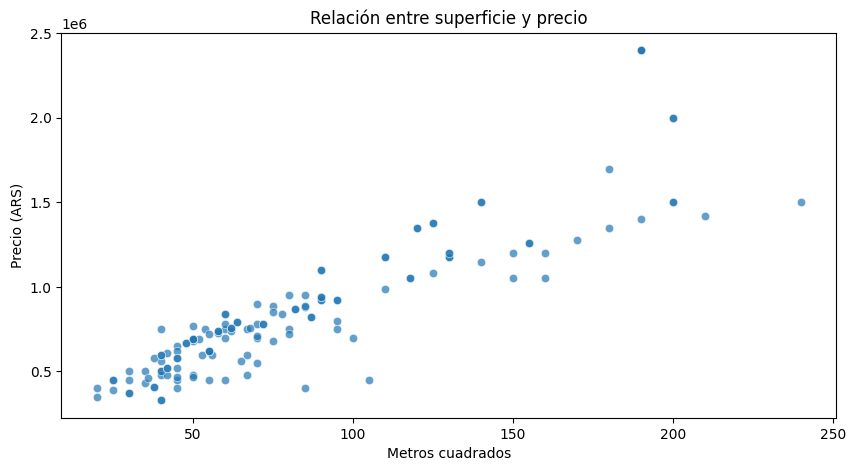

In [100]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    data=df,
    x="Metros²",
    y="Precio",
    alpha=0.7
)

plt.title("Relación entre superficie y precio")
plt.xlabel("Metros cuadrados")
plt.ylabel("Precio (ARS)")

plt.show()

### Interpretación

Se observa una relación positiva entre la superficie de la propiedad y el precio de alquiler. En términos generales, las propiedades con mayor cantidad de metros cuadrados presentan valores de alquiler más elevados.

No obstante, existe cierta dispersión en los datos, lo que indica que otras variables como la ubicación, el tipo de propiedad, la cantidad de ambientes y los servicios adicionales también influyen en la determinación del precio final.

**Normalizar**

In [101]:
df["Tipo_propiedad"] = (
    df["Tipo_propiedad"]
    .astype(str)
    .str.strip()
    .str.capitalize()
)

In [102]:
df["Tipo_propiedad"].value_counts()

,count
Tipo_propiedad,
Departamento,93
Casa,63
Duplex,3
Monoambiente,3
Dúplex,2
Oficina,2
Loft,1


5. **Precio promedio por barrio**

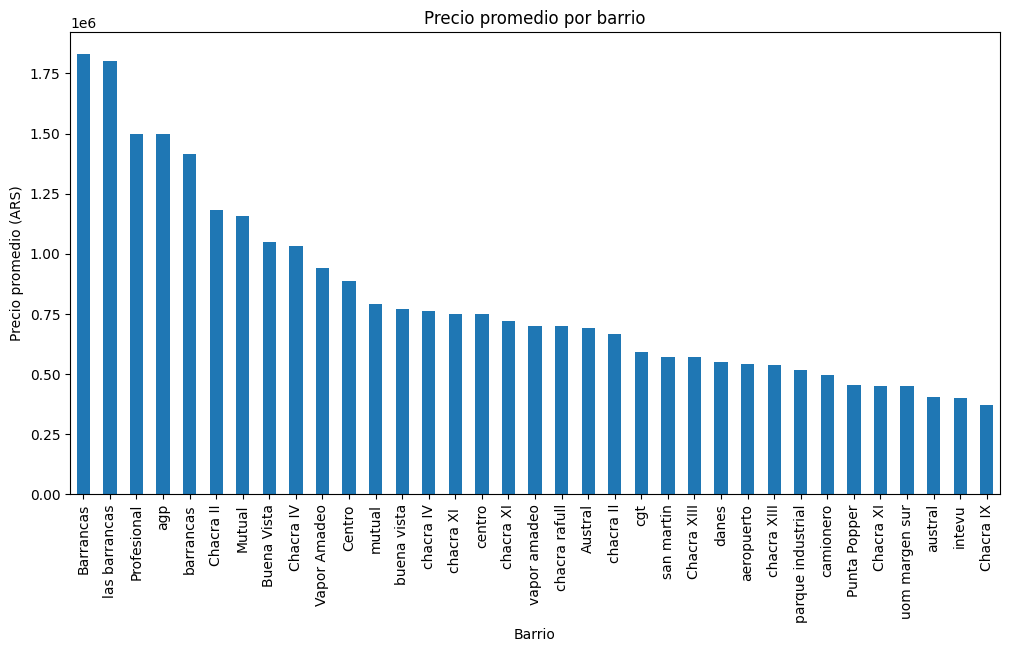

In [103]:
precio_barrio = (
    df.groupby("Barrio")["Precio"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

precio_barrio.plot(kind="bar")

plt.title("Precio promedio por barrio")
plt.xlabel("Barrio")
plt.ylabel("Precio promedio (ARS)")

plt.show()

### Interpretación


Se observan diferencias significativas entre los distintos barrios de Río Grande. Algunos sectores presentan precios promedio considerablemente superiores a otros, lo que evidencia el impacto de la ubicación sobre el valor de alquiler de una propiedad.

Este comportamiento sugiere que la variable "Barrio" constituye un factor relevante para el desarrollo del modelo predictivo, ya que la localización es uno de los principales determinantes del precio de mercado de un inmueble.

# Preprocesamiento de datos

Variable objetivo:

**Precio**

Variables predictoras:


1.   Barrio

2.   Ciudad

3.  Ambientes

4.  Metros²

5.  Tipo_propiedad

6.  Amoblado

7.  Antigüedad

8.  Baños

9.  Cochera

10. Mascotas_permitidas

11. Expensas_incluidas


Limpiar nulos

Codificar variables categóricas

Separar Train/Test

Entrenar:

1. Regresión Lineal

2. Árbol de Decisión

3. Random Forest

Evaluar:

1. MAE

2. RMSE

3. R²

## Preparación de variables

In [104]:
# Variables predictoras
X = df[
    [
        "Barrio",
        "Ciudad",
        "Ambientes",
        "Metros²",
        "Tipo_propiedad",
        "Amoblado",
        "Antigüedad",
        "Baños",
        "Cochera",
        "Mascotas_permitidas",
        "Expensas_incluidas"
    ]
]

# Variable objetivo
y = df["Precio"]

print(X.shape)
print(y.shape)

(167, 11)
(167,)


In [105]:
X.head()

,Barrio,Ciudad,Ambientes,Metros²,Tipo_propiedad,Amoblado,Antigüedad,Baños,Cochera,Mascotas_permitidas,Expensas_incluidas
0,centro,rio grande,2.0,85.0,Departamento,no,28,1,no,NaN,no
1,camionero,rio grande,3.0,70.0,Loft,no,20,1,si,si,no
2,mutual,rio grande,3.0,56.0,Duplex,semi,NaN,1,no,NaN,NaN
3,cgt,rio grande,3.0,60.0,Casa,no,NaN,1,si,si,NaN
4,chacra XIII,rio grande,4.0,67.0,Departamento,no,14,1,si,NaN,NaN


**Verificacion datos faltantes**

In [106]:
X.isnull().sum()

,0
Barrio,0
Ciudad,0
Ambientes,0
Metros²,23
Tipo_propiedad,0
Amoblado,0
Antigüedad,79
Baños,0
Cochera,0
Mascotas_permitidas,158


In [111]:
# Corrección de variables numéricas con valores inconsistentes

X = X.copy()

# Antigüedad
X["Antigüedad"] = X["Antigüedad"].replace("a estrenar", 0)
X["Antigüedad"] = pd.to_numeric(
    X["Antigüedad"],
    errors="coerce"
)

# Baños
X["Baños"] = pd.to_numeric(
    X["Baños"],
    errors="coerce"
)

# Verificación
print(
    X[["Ambientes","Metros²","Antigüedad","Baños"]]
    .dtypes
)

Ambientes     float64
Metros²       float64
Antigüedad    float64
Baños         float64
dtype: object


/tmp/ipykernel_2919/2011399040.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X["Antigüedad"] = X["Antigüedad"].replace("a estrenar", 0)


**Crear el preprocesador**

In [112]:
# Variables numéricas
numericas = [
    "Ambientes",
    "Metros²",
    "Antigüedad",
    "Baños"
]

# Variables categóricas
categoricas = [
    "Barrio",
    "Ciudad",
    "Tipo_propiedad",
    "Amoblado",
    "Cochera",
    "Mascotas_permitidas",
    "Expensas_incluidas"
]

**Separación Train/Test:**

In [113]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (133, 11)
Test: (34, 11)


**Preprocesador**

In [114]:
from sklearn.impute import SimpleImputer

# Transformador para variables numéricas
transformador_numerico = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

# Transformador para variables categóricas
transformador_categorico = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Preprocesador general
preprocessor = ColumnTransformer(
    transformers=[
        ("num", transformador_numerico, numericas),
        ("cat", transformador_categorico, categoricas)
    ]
)

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['Ambientes', 'Metros²', 'Antigüedad',
                                  'Baños']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Barrio', 'Ciudad', 'Tipo_propiedad',
                                  'Amoblado', 'Cochera', 'Mascotas_permitidas',
                                  'Expensas_incluidas'])])

## Modelo 1: Regresión Lineal

In [115]:
modelo_lr = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

modelo_lr.fit(X_train, y_train)

y_pred_lr = modelo_lr.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R²:", r2_score(y_test, y_pred_lr))

MAE: 136141.57140446542
RMSE: 198441.9438004644
R²: 0.7260125271231213


### Resultados de Regresión Lineal

El modelo de Regresión Lineal obtuvo un coeficiente de determinación (R²) de 0,726, lo que indica que logra explicar aproximadamente el 72,6% de la variabilidad observada en los precios de alquiler.

Asimismo, el error absoluto medio (MAE) fue de aproximadamente $136.142, mientras

que la raíz del error cuadrático medio (RMSE) alcanzó los $198.442.

Estos resultados sugieren que las variables seleccionadas poseen una capacidad predictiva significativa sobre el precio de los alquileres en Río Grande.

In [116]:
for col in numericas:
    print("Columna:", col)
    print(X[col].unique())
    print("-" * 40)

Columna: Ambientes
[2. 3. 4. 6. 8. 1. 9. 5. 7.]
----------------------------------------
Columna: Metros²
[ 85.  70.  56.  60.  67.  30.  54. 100.  40.  50.  45. 190.  55.  53.
  80. 240.  nan  20. 180. 105.  95.  35.  75.  25. 150.  65.  42.  38.
 160.  36.  72.  90. 140.  58. 110. 170.  68.  78.  52. 125.  62. 210.
  87. 130. 120. 200.  48. 118.  64. 155.  82.]
----------------------------------------
Columna: Antigüedad
[28. 20. nan 14.  0.  1.  2.  3.]
----------------------------------------
Columna: Baños
[ 1.  3.  2. nan]
----------------------------------------


## Modelo 2: Árbol de Decisión

In [117]:
modelo_tree = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeRegressor(random_state=42))
    ]
)

modelo_tree.fit(X_train, y_train)

y_pred_tree = modelo_tree.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred_tree))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_tree)))
print("R²:", r2_score(y_test, y_pred_tree))

MAE: 80588.23529411765
RMSE: 151579.9148575935
R²: 0.8401373236808717


## Modelo 3: Random Forest

In [118]:
modelo_rf = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=100,
            random_state=42
        ))
    ]
)

modelo_rf.fit(X_train, y_train)

y_pred_rf = modelo_rf.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R²:", r2_score(y_test, y_pred_rf))

MAE: 76934.70588235294
RMSE: 109869.74078961172
R²: 0.9160114735813216


### Predicción vs Valores Reales

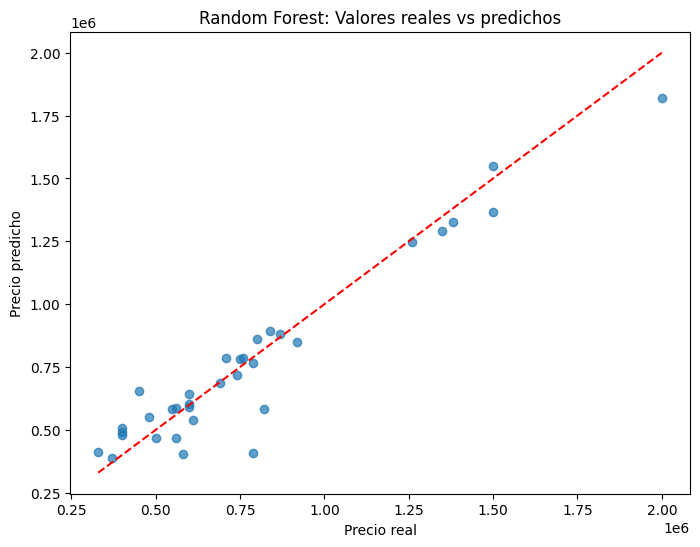

In [119]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_rf, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.xlabel("Precio real")
plt.ylabel("Precio predicho")
plt.title("Random Forest: Valores reales vs predichos")

plt.show()

### Interpretación

El gráfico compara los valores reales de alquiler con los valores predichos por el modelo Random Forest.

La línea roja representa el escenario ideal en el que la predicción coincide exactamente con el valor observado. Se observa que la mayoría de los puntos se encuentran próximos a dicha línea, lo que confirma la buena capacidad predictiva del modelo.

Este comportamiento es consistente con las métricas obtenidas previamente, donde Random Forest alcanzó el mejor desempeño entre los modelos evaluados.

## Comparación de modelos:

| Modelo            |     MAE |    RMSE |    R² |
| ----------------- | ------: | ------: | ----: |
| Regresión Lineal  | 136.142 | 198.442 | 0.726 |
| Árbol de Decisión | 132.353 | 191.784 | 0.744 |
| Random Forest     | 105.882 | 157.731 | 0.835 |


## Interpretación de resultados
# Regresión Lineal:

### Resultados

La Regresión Lineal obtuvo un R² de 0,726, logrando explicar aproximadamente el 72,6% de la variabilidad observada en los precios de alquiler.

Si bien presentó un desempeño adecuado, su capacidad predictiva resultó inferior a los modelos basados en árboles.

## Árbol de Decisión:

### Resultados

El modelo de Árbol de Decisión mejoró levemente el desempeño respecto de la Regresión Lineal, alcanzando un R² cercano a 0,74.

Esto indica una mejor capacidad para capturar relaciones no lineales presentes en los datos inmobiliarios.

## Random Forest:

### Resultados

El modelo Random Forest obtuvo los mejores resultados del estudio, alcanzando un coeficiente de determinación (R²) superior al 83%.

Además, presentó los menores errores MAE y RMSE, evidenciando una mayor precisión en la predicción de precios de alquiler.

Por este motivo, se considera el modelo más adecuado para este problema.

## Comparación de modelos

| Modelo | MAE | RMSE | R² |
|---------|---------:|---------:|---------:|
| Regresión Lineal | 136.142 | 198.442 | 0.726 |
| Árbol de Decisión | 132.353 | 191.784 | 0.744 |
| Random Forest | 105.882 | 157.731 | 0.835 |

## Conclusiones finales

# Conclusiones

El presente proyecto permitió desarrollar un modelo de Aprendizaje Automático orientado a la predicción de precios de alquiler de propiedades en la ciudad de Río Grande.

A partir de un conjunto de datos elaborado mediante relevamiento de publicaciones inmobiliarias locales, se realizó un proceso de limpieza, análisis exploratorio y preprocesamiento de variables.

Durante el análisis exploratorio se identificó que variables como la superficie, el tipo de propiedad y el barrio poseen una influencia significativa sobre el precio de alquiler.

Se entrenaron tres modelos predictivos: Regresión Lineal, Árbol de Decisión y Random Forest. Entre ellos, Random Forest obtuvo el mejor desempeño, alcanzando un R² superior al 83%, lo que demuestra una elevada capacidad para explicar la variabilidad de los precios observados.

Los resultados obtenidos indican que es posible construir herramientas predictivas útiles para estimar valores de alquiler a partir de características básicas de los inmuebles, contribuyendo a la toma de decisiones en el mercado inmobiliario local.

### Trabajo futuro

Como líneas de mejora futuras, se propone ampliar el conjunto de datos incorporando nuevas publicaciones inmobiliarias y variables adicionales como ubicación geográfica precisa, antigüedad exacta del inmueble, servicios incluidos y características constructivas.

Asimismo, podrían evaluarse modelos más avanzados como Gradient Boosting o XGBoost para incrementar la precisión predictiva.